Setup

In [5]:
from pathlib import Path
import sys

import torch
import torch.nn as nn

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataloader import create_dataloaders
from src.models.resnet50 import (
    create_resnet50,
    unfreeze_resnet_layer4,
)
from src.training.trainer import train_model
from src.utils.seed import set_seed

set_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


Load same shared train/validation data:

In [6]:
loaders = create_dataloaders(
    dataset_root=PROJECT_ROOT / "data/raw/garbage-dataset",
    manifest_dir=PROJECT_ROOT / "data/manifests",
    batch_size=32,
    num_workers=0,
)

train_loader = loaders["train_loader"]
val_loader = loaders["val_loader"]
class_to_idx = loaders["class_to_idx"]

Recreate ResNet50 and load Experiment 1

In [7]:
model = create_resnet50(
    num_classes=10,
    pretrained=True,
    freeze_backbone=True,
)

checkpoint_path = (
    PROJECT_ROOT
    / "results"
    / "checkpoints"
    / "resnet50_frozen_best.pth"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)

print(
    "Loaded frozen model from epoch:",
    checkpoint["epoch"],
)

Loaded frozen model from epoch: 9


In [8]:
model = unfreeze_resnet_layer4(model)

Check trainable parameters

In [9]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(
    f"Trainable percentage: "
    f"{100 * trainable_params / total_params:.2f}%"
)

Total parameters:     23,528,522
Trainable parameters: 14,985,226
Trainable percentage: 63.69%


In [10]:
for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print(name)

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.conv3.weight
layer4.0.bn3.weight
layer4.0.bn3.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
layer4.1.conv3.weight
layer4.1.bn3.weight
layer4.1.bn3.bias
layer4.2.conv1.weight
layer4.2.bn1.weight
layer4.2.bn1.bias
layer4.2.conv2.weight
layer4.2.bn2.weight
layer4.2.bn2.bias
layer4.2.conv3.weight
layer4.2.bn3.weight
layer4.2.bn3.bias
fc.weight
fc.bias


## Use a much smaller learning rate

In [17]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters(),
    ),
    lr=0.0001,
    weight_decay=0.0001,
)

Fine-tune for 5 epochs initially

In [12]:
finetune_checkpoint_path = (
    PROJECT_ROOT
    / "results"
    / "checkpoints"
    / "resnet50_layer4_finetuned_best.pth"
)

finetune_history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=5,
    checkpoint_path=finetune_checkpoint_path,
)


Epoch 1/5


Training:   0%|          | 0/433 [00:00<?, ?it/s]

Validation:   0%|          | 0/93 [00:00<?, ?it/s]

Train Loss: 0.1135 | Train Acc: 0.9625
Val Loss:   0.1333 | Val Acc:   0.9612
Time: 216.5s
Best model saved (val_loss=0.1333)

Epoch 2/5


Training:   0%|          | 0/433 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/93 [00:00<?, ?it/s]

Train Loss: 0.0253 | Train Acc: 0.9921
Val Loss:   0.1336 | Val Acc:   0.9632
Time: 144.9s

Epoch 5/5


Training:   0%|          | 0/433 [00:00<?, ?it/s]

Validation:   0%|          | 0/93 [00:00<?, ?it/s]

Train Loss: 0.0177 | Train Acc: 0.9949
Val Loss:   0.1296 | Val Acc:   0.9659
Time: 143.7s


Load the best fine-tuned checkpoint and run exactly the same validation metric calculation

In [13]:
from src.evaluation.metrics import (
    collect_predictions,
    calculate_classification_metrics,
)

In [14]:
class_names = [
    class_name
    for class_name, index in sorted(
        class_to_idx.items(),
        key=lambda item: item[1],
    )
]

print(class_names)

['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [15]:
checkpoint = torch.load(
    finetune_checkpoint_path,
    map_location=device,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Best fine-tuning epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["val_loss"])
print("Validation accuracy:", checkpoint["val_accuracy"])

y_true, y_pred, y_prob = collect_predictions(
    model=model,
    dataloader=val_loader,
    device=device,
)

metrics, report, matrix = calculate_classification_metrics(
    y_true=y_true,
    y_pred=y_pred,
    class_names=class_names,
)

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

Best fine-tuning epoch: 3
Best validation loss: 0.12801878098096803
Validation accuracy: 0.9659244264507423
accuracy: 0.9659
macro_precision: 0.9589
macro_recall: 0.9584
macro_f1: 0.9584
weighted_f1: 0.9660


Per-class classification report 

In [16]:
import pandas as pd

report_df = pd.DataFrame(report).transpose()

display(
    report_df[
        ["precision", "recall", "f1-score", "support"]
    ]
)

,precision,recall,f1-score,support
battery,0.951724,0.971831,0.961672,142.000000
biological,0.986395,0.966667,0.976431,150.000000
cardboard,0.960573,0.978102,0.969259,274.000000
clothes,0.996188,0.981227,0.988651,799.000000
glass,0.959315,0.976035,0.967603,459.000000
metal,0.903846,0.921569,0.912621,153.000000
paper,0.979757,0.960317,0.969940,252.000000
plastic,0.961404,0.922559,0.941581,297.000000
shoes,0.927215,0.989865,0.957516,296.000000
trash,0.962963,0.915493,0.938628,142.000000


In [18]:
report_path = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "resnet50_finetuned_validation_report.csv"
)

report_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

report_df.to_csv(report_path)

print("Saved:", report_path)

Saved: c:\Users\USER\Desktop\SLIIT\DL\Assignment\waste-classification\results\tables\resnet50_finetuned_validation_report.csv


Generate the confusion matrix

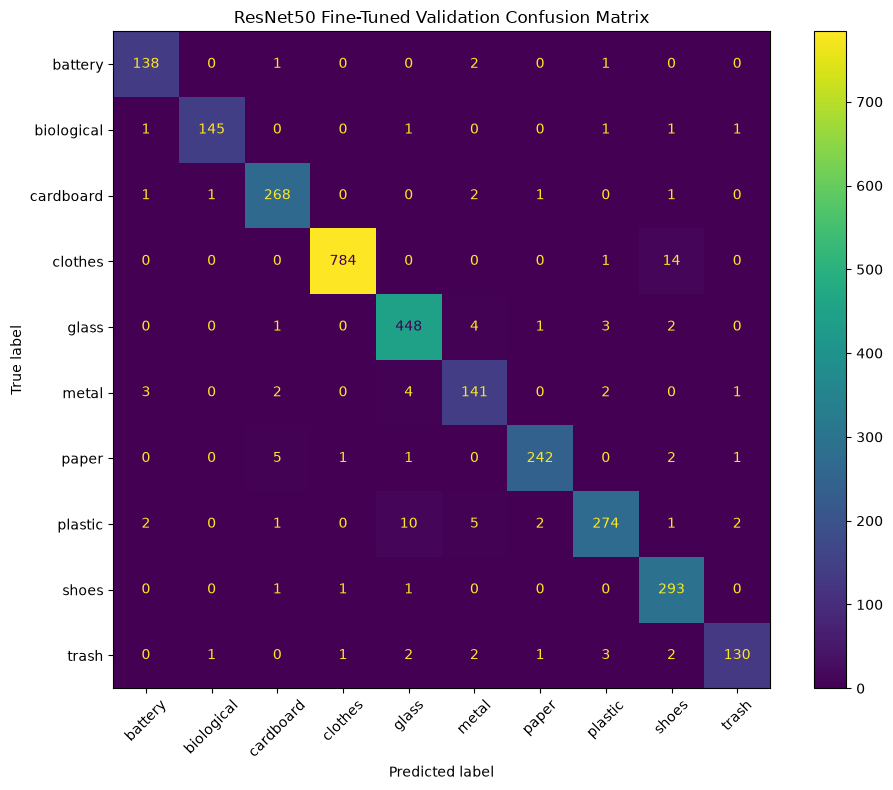

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(
    figsize=(10, 8)
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=class_names,
)

display_cm.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
)

plt.title(
    "ResNet50 Fine-Tuned Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

Calculate multiclass one-vs-rest ROC-AUC:

In [20]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_true_binary = label_binarize(
    y_true,
    classes=range(len(class_names)),
)

macro_roc_auc = roc_auc_score(
    y_true_binary,
    y_prob,
    average="macro",
    multi_class="ovr",
)

weighted_roc_auc = roc_auc_score(
    y_true_binary,
    y_prob,
    average="weighted",
    multi_class="ovr",
)

print(
    f"Macro ROC-AUC: {macro_roc_auc:.4f}"
)

print(
    f"Weighted ROC-AUC: {weighted_roc_auc:.4f}"
)

Macro ROC-AUC: 0.9986
Weighted ROC-AUC: 0.9987


## Save Experiment Results

In [21]:
import pandas as pd

results_dir = PROJECT_ROOT / "results" / "tables"
results_dir.mkdir(parents=True, exist_ok=True)

experiment_results = {
    "model": "ResNet50",
    "experiment": "Layer4 Fine-Tuning",
    "best_epoch": checkpoint["epoch"],
    "val_loss": checkpoint["val_loss"],
    "accuracy": metrics["accuracy"],
    "macro_precision": metrics["macro_precision"],
    "macro_recall": metrics["macro_recall"],
    "macro_f1": metrics["macro_f1"],
    "weighted_f1": metrics["weighted_f1"],
    "macro_roc_auc": macro_roc_auc,
    "weighted_roc_auc": weighted_roc_auc,
}

results_df = pd.DataFrame(
    [experiment_results]
)

results_path = (
    results_dir
    / "resnet50_finetuned_validation_summary.csv"
)

results_df.to_csv(
    results_path,
    index=False,
)

display(results_df)

print("Saved:", results_path)

,model,experiment,best_epoch,val_loss,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_roc_auc,weighted_roc_auc
0,ResNet50,Layer4 Fine-Tuning,3,0.128019,0.965924,0.958938,0.958366,0.95839,0.96595,0.998611,0.998738


Saved: c:\Users\USER\Desktop\SLIIT\DL\Assignment\waste-classification\results\tables\resnet50_finetuned_validation_summary.csv


## Model Selection Decision

The partially fine-tuned ResNet50 was selected as the final ResNet50
configuration based on validation-set performance.

Compared with the frozen-backbone baseline, fine-tuning layer4 improved
validation accuracy from 94.97% to 96.59% and macro F1 from 93.94% to
95.84%.

The fine-tuned model achieved a macro ROC-AUC of 0.9986 and weighted
ROC-AUC of 0.9987. Per-class evaluation showed strong performance across
all ten classes, although metal, plastic, and trash produced relatively
lower F1 scores than the other categories.

No test-set results were used during model selection or hyperparameter
decisions.